## Analyze parameter estimation results for single enzyme reaction models fit to Pyruvate Kinase data
#### Nathaniel Linden - 2024-10-27
#### Edited by Annette Thompson - 2026

In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib as mpl
import seaborn as sns
import met_brewer as mb
import jax
from scipy.interpolate import interp1d

# set plot style and import helper functions
plt.style.use('default')
mpl.rcParams['figure.autolayout'] = True
colors = mb.met_brew(name="Veronese", n=7)

from utils import *

# set Jax to use 64-bit precision and CPU
jax.config.update('jax_enable_x64', True)
jax.config.update('jax_platform_name', 'cpu')

save_path = './results/MA/'

#### Load data + results

In [2]:
# pyruvate kinase data
pyr_kin_dat = pd.read_csv('./data/Duggleby_Clarke_1991_Fig2.csv')
times = pyr_kin_dat['time'].to_numpy()
data = pyr_kin_dat['conc (mM)'].to_numpy()

# Create an interpolation function
interp_func = interp1d(times, data, kind='cubic')

# Generate new times with 10 points between each original point
new_times = np.linspace(times.min(), times.max(), len(times) * 10)

# Interpolate data at new times
new_data = interp_func(new_times)

# Save the new data and new times into a csv
interp_df = pd.DataFrame({'time': new_times, 'conc (mM)': new_data})
interp_df.to_csv('./data/Duggleby_Clarke_1991_Fig2_interp.csv', index=False)

In [3]:
# load inferences
inf_data_MA_no_pred = az.from_netcdf(save_path + 'MA_mcmc_samples_pm.nc')
if 'prediction' in inf_data_MA_no_pred.posterior:
    del inf_data_MA_no_pred.posterior['prediction']
inf_data_MA = az.from_netcdf(save_path + 'MA_mcmc_samples_pm.nc')

## Plots
1. Traces and marginals
2. Parameter estimate marginals
3. Prior/posterior predictive checks

#### Traces

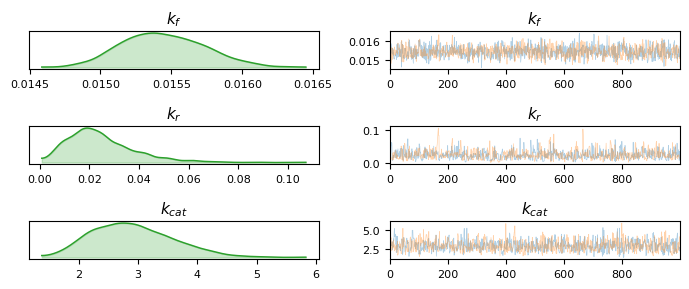

In [4]:
# MA
MA = az.plot_trace(inf_data_MA_no_pred, figsize=(7, 3), compact=True, divergences=False, 
                   combined=True, chain_prop='color', fill_kwargs={'alpha': 0.24},
                   trace_kwargs={'linewidth': 0.5})
param_names = {'k_f': r'$k_f$', 'k_r': r'$k_r$', 'k_cat': r'$k_{cat}$', 'V_max': r'$V_{max}$', 'K_m': r'$K_m$', 'n': r'$n$'}
for ax in MA.ravel():
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontsize(8)
    ax.ticklabel_format(style='plain', axis='x')
    ax.set_title(param_names[ax.get_title()], fontsize=11, fontweight='bold')
plt.savefig(save_path + 'MA_trace.png', dpi=500)

#### MCMC Convergence Metrics

In [5]:
print('Mass Action:')
print(az.summary(inf_data_MA_no_pred, kind='diagnostics'))

Mass Action:
       mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
k_f        0.000    0.000    1296.0    1308.0    1.0
k_r        0.000    0.001     775.0     566.0    1.0
k_cat      0.023    0.018     905.0    1010.0    1.0


#### marginal distributions of the parameter estimates:

/var/folders/41/tc0sn5mn46g26bhzv3slfbd80000gn/T/ipykernel_57581/3099964639.py:14: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(save_path + 'MA_hist.pdf', transparent=True, bbox_inches='tight')
/var/folders/41/tc0sn5mn46g26bhzv3slfbd80000gn/T/ipykernel_57581/3099964639.py:14: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(save_path + 'MA_hist.pdf', transparent=True, bbox_inches='tight')
/opt/anaconda3/envs/Bayesian/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


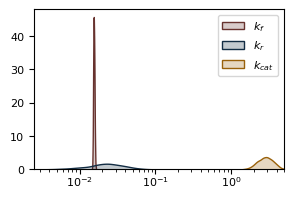

In [6]:
# MA
MA_names = {'k_cat': r'$k_{cat}$', 'k_f': r'$k_{f}$', 'k_r': r'$k_{r}$',}
fig, ax = get_sized_fig_ax(2.5, 1.6)
for idx,param in enumerate(list(inf_data_MA_no_pred.posterior.data_vars.keys())):
    sns.kdeplot(inf_data_MA_no_pred.posterior[param].values.flatten(), color=colors[idx+1], ax=ax, fill=True, label=MA_names[param], linewidth=1.0, log_scale=True)
ax.set_xlabel('', fontsize=8)
ax.xaxis.set_label_coords(0.5, -0.25)
ax.set_ylabel('', fontsize=8)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontsize(8)
plt.legend(fontsize=8)
ax.xaxis.set_tick_params(pad=0)
ax.set_xlim(2.5e-3, 5e0)
plt.savefig(save_path + 'MA_hist.pdf', transparent=True, bbox_inches='tight')

#### Prior/posterior predictive checks

[<matplotlib.lines.Line2D object at 0x13173df90>, <matplotlib.collections.PathCollection object at 0x1314a3380>]


/Users/annettethompson/Downloads/Linden 2025/utils.py:180: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.draw()
/Users/annettethompson/Downloads/Linden 2025/utils.py:182: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(filename, dpi="figure", bbox_inches=bbox, transparent=True)
/var/folders/41/tc0sn5mn46g26bhzv3slfbd80000gn/T/ipykernel_57581/2606809489.py:7: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig_MA.savefig(save_path + 'MA_predictive.pdf', transparent=True, bbox_inches='tight')
/opt/anaconda3/envs/Bayesian/lib/python3.13/site-packages/IPython/core/events.py:96: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  func(*args, **kwargs)
/opt/anaconda3/envs/Bayesian/lib/python3.13/site-package

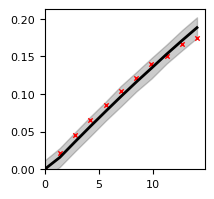

In [7]:
f_size = (1.6, 1.6)

fig_MA, ax_MA, leg_MA = plot_predictive(inf_data_MA, data, times, plot_prior=False, n_traces=0,
                          figsize=f_size, cred_int=99)
export_legend(leg_MA, save_path + 'MA_predictive_legend.pdf')
leg_MA.remove()
fig_MA.savefig(save_path + 'MA_predictive.pdf', transparent=True, bbox_inches='tight')

#### Compute ELPPD for model comparison

In [8]:
print("The PSIS_LOO_CV estimate of the ELPD for the MA model is: ", az.loo(inf_data_MA))

The PSIS_LOO_CV estimate of the ELPD for the MA model is:  Computed from 2000 posterior samples and 11 observations log-likelihood matrix.

         Estimate       SE
elpd_loo    33.56     4.93
p_loo        3.51        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)        9   81.8%
   (0.70, 1]   (bad)         1    9.1%
   (1, Inf)   (very bad)    1    9.1%



/opt/anaconda3/envs/Bayesian/lib/python3.13/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


In [9]:
inf_data_MA

Inference data with groups:
	> posterior
	> posterior_predictive
	> log_likelihood
	> sample_stats
	> prior
	> prior_predictive
	> observed_data